In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

aa = ['SCA', 'SCV', 'SCL', 'SCI', 'SCC', 'SCM', 'SCS', 'SCT','SCN', 'SCQ',
    'SCF', 'SCY', 'SCW', 'SCP', 'GLYD', 'SCHE', 'SCHD', 'SCDN', 'SCEN', 'SCKN', 'SCRN',
    'SCHP-N', 'SCD-N', 'SCE-N', 'SCCM-N', 'SCYM', 'SCK-N', 'SCR-N', 'SCRN-1', 'SCW-1']
names = ['sca', 'scv', 'scl', 'sci', 'scc', 'scm', 'scs', 'sct', 'scn', 'scq',
         'scf', 'scy', 'scw', 'scp', 'glyd', 'sche', 'schd', 'scdn', 'scen', 'sckn', 'scrn',
         'schp', 'scd', 'sce', 'sccm', 'scym', 'sck', 'scr', 'scrn-1', 'scw-1',
        'scf-1', 'scy-1', 'scv-1', 'sci-1', 'scl-1', 'scm-1']
ll = ['A', 'V', 'I', 'L', 'C$^{0}$', 'M', 'S', 'T', 'N', 'Q',
      'F', 'Y$^{0}$', 'W', 'P', 'GLYD',  'HSE$^{0}$', 'HSD$^{0}$', 'D$^{0}$', 'E$^{0}$', 'K$^{0}$',
      'R$^{0}$', 'HSP$^{+}$', 'D$^{-}$', 'E$^{-}$', 'C$^{-}$', 'Y$^{-}$', 'K$^{+}$', 'R$^{+}$', 'R$^{0}$ (0.1M)', 'W (0.1M)',
     'F(0.1M)', 'Y$^{0}$ (0.1M)', 'V (0.1M)', 'L (0.1M)', 'I (0.1M)', 'M (0.1M)']
label = ['ALA', 'VAL', 'LEU', 'ILE', 'CYS', 'MET', 'SER', 'THR', 'ASN', 'GLN',
         'PHE', 'TYR', 'TRP', 'PRO', 'GLYD', 'HSE', 'HSD', 'ASP$^{0}$', 'GLU$^{0}$', 'LYS$^{0}$',
         'ARG$^{0}$', 'HSP$^{+}$', 'ASP$^{-}$', 'GLU$^{-}$', 'CYS$^{-}$', 'TYR$^{-}$', 'LYS$^{+}$', 'ARG$^{+}$']

N_MAIN = 28  # main analogs (without 0.1M variants)
# 0.1M variants: data row index → x position of counterpart
VARIANTS_01M = {28: 20, 29: 12, 30: 10 , 31: 11, 32: 1, 33: 3, 34: 2, 35: 5}  # scrn-1 → scrn (R⁰), scw-1 → scw (W)...etc
VARIANTS_01M_LABELS = {28: 'R$^{0}$\n(0.1M)', 29: 'W\n(0.1M)', 30: 'F\n(0.1M)', 31: 'Y\n(0.1M)', 32: 'V\n(0.1M)', 33: 'I\n(0.1M)', 34: 'L\n(0.1M)', 35: 'M\n(0.1M)', }

# Paths
data = '../data/'
plots = '../plot/'
computed = data + 'SUPP_membrane_parm/'

# Pre-computed CSVs
csv_apl = computed + 'computed_apl.csv'
csv_thk = computed + 'computed_thickness.csv'
csv_acm = computed + 'computed_acm.csv'
csv_dens_dev = computed + 'computed_density_deviation.csv'
csv_order_dev = computed + 'computed_order_deviation.csv'

# POPC order parameter (kept for line plot)
order_popc = data + 'SUPP_membrane_parm/order_parameter/popc-chain{}.dat'

# Category ranges for alternating backgrounds
category_ranges = [
    (0, 3),    # Aliphatic (A, V, L, I)
    (4, 5),    # Cys/Met (C⁰, M)
    (6, 9),    # Polar (S, T, N, Q)
    (10, 12),  # Aromatic (F, Y⁰, W)
    (13, 14),  # GLYD, P
    (15, 20),  # Neutral forms of ionizable
    (21, 27),  # Charged forms
]
rotated_indices = [14, 15, 16, 21]

In [2]:
# POPC reference values from pre-computed CSVs
df_apl = pd.read_csv(csv_apl)
popc_apl = df_apl[df_apl['label'] == 'POPC'].iloc[0]
apl_popc, apl_se_popc = popc_apl['apl'], popc_apl['std_error']
print('ApL :', apl_popc, apl_se_popc)

df_thk = pd.read_csv(csv_thk)
popc_thk = df_thk[df_thk['label'] == 'POPC'].iloc[0]
thk_popc, thk_se_popc = popc_thk['thickness'], popc_thk['std_error']
print('DP-P :', thk_popc, thk_se_popc)

df_acm = pd.read_csv(csv_acm)
popc_acm = df_acm[df_acm['label'] == 'POPC'].iloc[0]
acm_popc, acm_se_popc = popc_acm['acm'], popc_acm['std_error']
print('Ka :', acm_popc, acm_se_popc)

ApL : 64.6086 0.0559
DP-P : 39.117 0.0325
Ka : 225.53449447136256 6.36479070094909


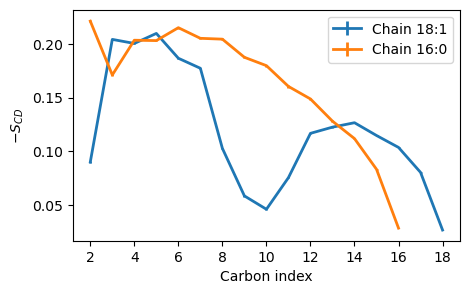

In [3]:
#ORDER PARAMETER -- POPC ONLY
prop_cycle = plt.rcParams['axes.prop_cycle']
color=prop_cycle.by_key()['color']

plt.figure(figsize=(5,3))
#POPC Scd
chain=[2, 3]
for c in chain:
    df = pd.read_csv(order_popc.format(c), sep='\t')
    x, y, e = df['Carbon'], df['scd_mean'], df['se']
    if c==2:
        plt.errorbar(x, y, e, label='Chain 18:1', fmt='-', color=color[0], linewidth=2.0, alpha=1)
    elif c==3:
        plt.errorbar(x, y, e, label='Chain 16:0', fmt='-', color=color[1], linewidth=2.0, alpha=1)

plt.legend(loc='upper right')
plt.xlabel('Carbon index')
plt.ylabel('$-S_{CD}$')
plt.savefig(plots+'FigureS4.png', bbox_inches='tight', transparent=True)
plt.show()

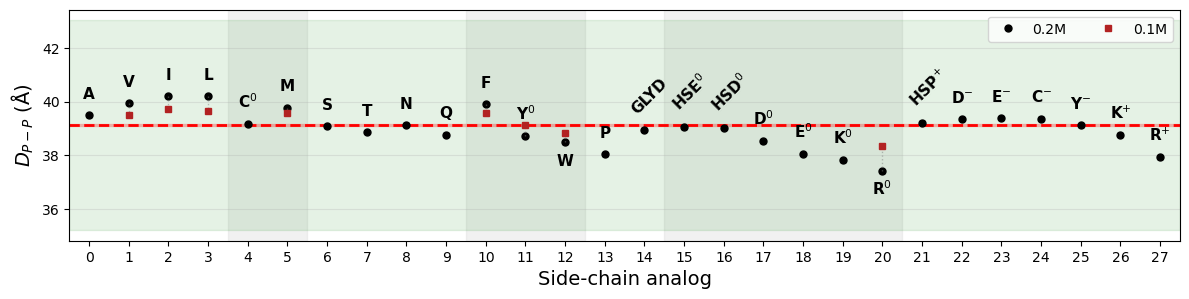

In [4]:
# THICKNESS -- PLOT
df = pd.read_csv(csv_thk)
df = df[df['label'] != 'POPC'].reset_index(drop=True)

x_pos = np.arange(N_MAIN)

fig, ax = plt.subplots(figsize=(12, 3))

# Add alternating backgrounds
for i, (start, end) in enumerate(category_ranges):
    if i % 2 == 1:
        ax.axvspan(start - 0.5, end + 0.5, color='lightgray', alpha=0.3, zorder=0)

# Reference lines (POPC ± 10% and ± SE)
ref, se = thk_popc, thk_se_popc
ax.fill_between([-0.5, N_MAIN - 0.5], [ref - 0.1*ref]*2, [ref + 0.1*ref]*2, 
                color='green', alpha=0.1, zorder=1)
ax.fill_between([-0.5, N_MAIN - 0.5], [ref - se]*2, [ref + se]*2, 
                color='red', alpha=0.2, zorder=1)
ax.axhline(y=ref, color='r', linestyle='--', linewidth=2, zorder=2)

# Main data points
ax.errorbar(x_pos, df['thickness'][:N_MAIN], df['std_error'][:N_MAIN], color='k', fmt='o', markersize=5, 
            linewidth=1, capsize=2, zorder=3)
ax.plot([], [], 'o', color='k', markersize=5, label='0.2M')
# 0.1M variants as red dots with connecting line
for idx, xmap in VARIANTS_01M.items():
    ax.plot([xmap, xmap], [df['thickness'][xmap], df['thickness'][idx]],
            color='grey', linestyle=':', linewidth=1, alpha=0.5, zorder=4)
    ax.errorbar(xmap, df['thickness'][idx], df['std_error'][idx], color='firebrick', fmt='s', markersize=5,
                linewidth=1, capsize=2, zorder=5)
ax.plot([], [], 's', color='firebrick', markersize=5, label='0.1M')

ax.set_xlabel('Side-chain analog', fontsize=14)
ax.set_ylabel('$D_{P-P}$ (Å)', fontsize=14)
ax.set_xlim(-0.5, N_MAIN - 0.5)
ax.set_xticks(x_pos)
ax.grid(axis='y', alpha=0.3, zorder=1)
ax.legend(loc='upper right', fontsize=10, ncol=2)

# Labels on top (with rotation for GLYD and Histidines)
for i, (val, label) in enumerate(zip(df['thickness'][:N_MAIN], ll[:N_MAIN])):
    offset_y = 0.5
    if i in rotated_indices:
        ax.text(x_pos[i] - 0.4, val + offset_y, label, ha='left', va='bottom', 
                fontsize=11, fontweight='bold', rotation=45)
    elif i in [12, 20]:
        ax.text(x_pos[i], val - 1, label, ha='center', va='bottom', 
                fontsize=11, fontweight='bold')
    else:
        ax.text(x_pos[i], val + offset_y, label, ha='center', va='bottom', 
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig(plots + 'FigureS1.png', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

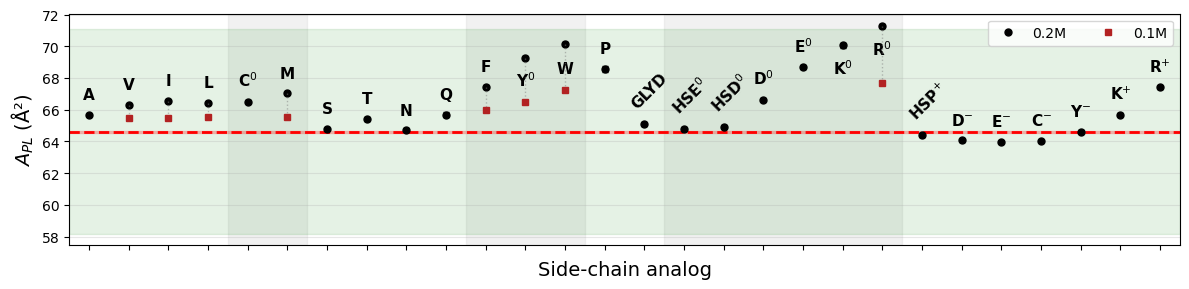

In [5]:
# AREA PER LIPID -- PLOT
df = pd.read_csv(csv_apl)
df = df[df['label'] != 'POPC'].reset_index(drop=True)

x_pos = np.arange(N_MAIN)

fig, ax = plt.subplots(figsize=(12, 3))

# Add alternating backgrounds
for i, (start, end) in enumerate(category_ranges):
    if i % 2 == 1:
        ax.axvspan(start - 0.5, end + 0.5, color='lightgray', alpha=0.3, zorder=0)

# Reference lines (POPC ± 10% and ± SE)
ref, se = apl_popc, apl_se_popc
ax.fill_between([-0.5, N_MAIN - 0.5], [ref - 0.1*ref]*2, [ref + 0.1*ref]*2, 
                color='green', alpha=0.1, zorder=1)
ax.fill_between([-0.5, N_MAIN - 0.5], [ref - se]*2, [ref + se]*2, 
                color='red', alpha=0.2, zorder=1)
ax.axhline(y=ref, color='r', linestyle='--', linewidth=2, zorder=2)

# Main data points
ax.errorbar(x_pos, df['apl'][:N_MAIN], df['std_error'][:N_MAIN], color='k', fmt='o', markersize=5, 
            linewidth=1, capsize=2, zorder=3)

ax.plot([], [], 'o', color='k', markersize=5, label='0.2M')
# 0.1M variants as red dots with connecting line
for idx, xmap in VARIANTS_01M.items():
    ax.plot([xmap, xmap], [df['apl'][xmap], df['apl'][idx]],
            color='grey', linestyle=':', linewidth=1, alpha=0.5, zorder=4)
    ax.errorbar(xmap, df['apl'][idx], df['std_error'][idx], color='firebrick', fmt='s', markersize=5,
                linewidth=1, capsize=2, zorder=5)
ax.plot([], [], 's', color='firebrick', markersize=5, label='0.1M')

# Labels on top (with rotation for GLYD and Histidines)
for i, (val, label) in enumerate(zip(df['apl'][:N_MAIN], ll[:N_MAIN])):
    offset_y = 0.8
    if i in rotated_indices:
        ax.text(x_pos[i] - 0.4, val + offset_y, label, ha='left', va='bottom', 
                fontsize=11, fontweight='bold', rotation=45)
    elif i in [11, 12, 19, 20]:
        ax.text(x_pos[i], val - 2, label, ha='center', va='bottom', 
                fontsize=11, fontweight='bold')
    else:
        ax.text(x_pos[i], val + offset_y, label, ha='center', va='bottom', 
                fontsize=11, fontweight='bold')

ax.set_xlabel('Side-chain analog', fontsize=14)
ax.set_ylabel('$A_{PL}$ (Å²)', fontsize=14)
ax.set_xlim(-0.5, N_MAIN - 0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([])
ax.grid(axis='y', alpha=0.3, zorder=1)
ax.legend(loc='upper right', fontsize=10, ncol=2)

plt.tight_layout()
plt.savefig(plots + 'FigureS2.png', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

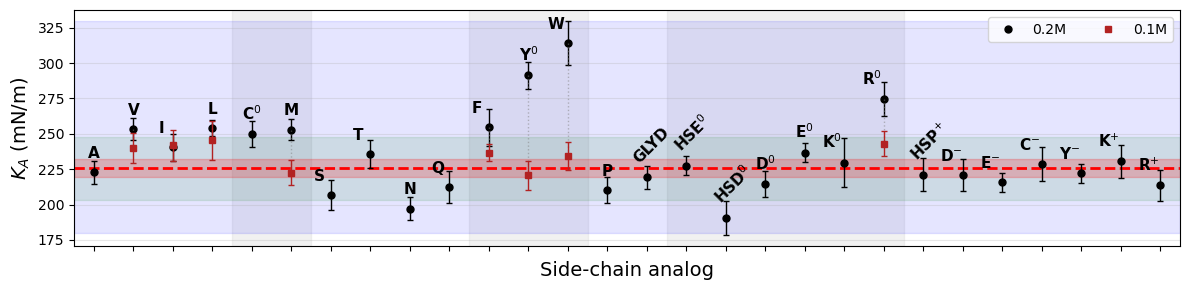

In [6]:
# AREA COMPRESSIBILITY MODULUS -- from pre-computed CSV
df = pd.read_csv(csv_acm)
df = df[df['label'] != 'POPC'].reset_index(drop=True)

x_pos = np.arange(N_MAIN)

fig, ax = plt.subplots(figsize=(12, 3))

# Add alternating backgrounds
for i, (start, end) in enumerate(category_ranges):
    if i % 2 == 1:
        ax.axvspan(start - 0.5, end + 0.5, color='lightgray', alpha=0.3, zorder=0)

# Reference lines (POPC ± 10% and ± SE)
ref, se = acm_popc, acm_se_popc

# Experimental range
ax.fill_between([-0.5, N_MAIN - 0.5], [180]*2, [330]*2, 
                color='blue', alpha=0.1, zorder=1)
ax.fill_between([-0.5, N_MAIN - 0.5], [ref - 0.1*ref]*2, [ref + 0.1*ref]*2, 
                color='green', alpha=0.1, zorder=1)
ax.fill_between([-0.5, N_MAIN - 0.5], [ref - se]*2, [ref + se]*2, 
                color='red', alpha=0.2, zorder=1)
ax.axhline(y=ref, color='r', linestyle='--', linewidth=2, zorder=2)

# Main data points
ax.errorbar(x_pos, df['acm'][:N_MAIN], df['std_error'][:N_MAIN], color='k', fmt='o', markersize=5, 
            linewidth=1, capsize=2, zorder=3)
ax.plot([], [], 'o', color='k', markersize=5, label='0.2M')
# 0.1M variants as red dots with connecting line
for idx, xmap in VARIANTS_01M.items():
    ax.plot([xmap, xmap], [df['acm'][xmap], df['acm'][idx]],
            color='grey', linestyle=':', linewidth=1, alpha=0.5, zorder=4)
    ax.errorbar(xmap, df['acm'][idx], df['std_error'][idx], color='firebrick', fmt='s', markersize=5,
                linewidth=1, capsize=2, zorder=5)
ax.plot([], [], 's', color='firebrick', markersize=5, label='0.1M')

# Labels on top (with rotation for GLYD and Histidines)
for i, (val, label) in enumerate(zip(df['acm'][:N_MAIN], ll[:N_MAIN])):
    offset_y = 8
    if i in rotated_indices:
        ax.text(x_pos[i] - 0.4, val + offset_y, label, ha='left', va='bottom', 
                fontsize=11, fontweight='bold', rotation=45)
    elif i in [2, 6, 7, 9, 10, 12, 19, 20, 22, 23, 24, 25, 26, 27]:
        ax.text(x_pos[i]-0.3, val  + offset_y, label, ha='center', va='bottom', 
                fontsize=11, fontweight='bold')
    else:
        ax.text(x_pos[i], val + offset_y, label, ha='center', va='bottom', 
                fontsize=11, fontweight='bold')

ax.set_xlabel('Side-chain analog', fontsize=14)
ax.set_ylabel('$K_A$ (mN/m)', fontsize=14)
ax.set_xlim(-0.5, N_MAIN - 0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([])
ax.grid(axis='y', alpha=0.3, zorder=1)
ax.legend(loc='upper right', fontsize=10, ncol=2)

plt.tight_layout()
plt.savefig(plots + 'FigureS3.png', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

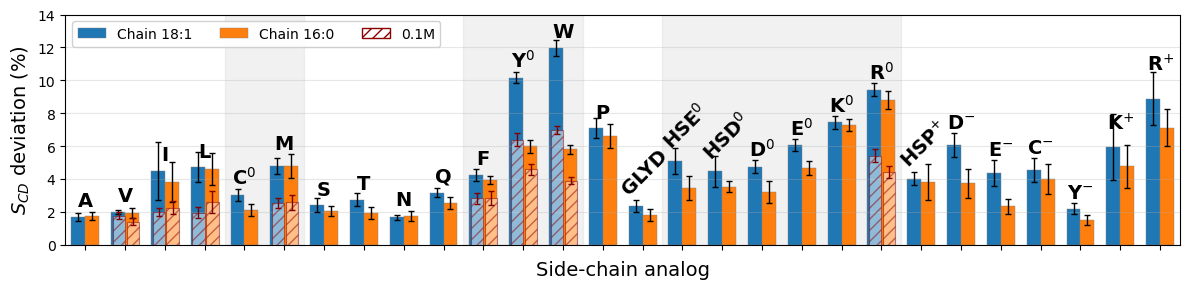

In [7]:
# ABC DEVIATION BETWEEN ORDER PARAMETER CURVES -- from pre-computed CSV
from matplotlib.patches import Patch

df_od = pd.read_csv(csv_order_dev)

chain_label = ['Chain 18:1', 'Chain 16:0']
data_chains = [df_od['chain_18_1_mean'].tolist(), df_od['chain_16_0_mean'].tolist()]
se_chains = [df_od['chain_18_1_se'].tolist(), df_od['chain_16_0_se'].tolist()]

prop_cycle = plt.rcParams['axes.prop_cycle']
default_colors = prop_cycle.by_key()['color']

x_pos = np.arange(N_MAIN)
bar_width = 0.35
offset = bar_width / 2

fig, ax = plt.subplots(figsize=(12, 3))

for i, (start, end) in enumerate(category_ranges):
    if i % 2 == 1:
        ax.axvspan(start - 0.5, end + 0.5, color='lightgray', alpha=0.3, zorder=0)

# Main bars (first 28)
ax.bar(x_pos - offset, data_chains[0][:N_MAIN], bar_width, label=chain_label[0], 
       color=default_colors[0], edgecolor='grey', linewidth=0.3)
ax.errorbar(x_pos - offset, data_chains[0][:N_MAIN], se_chains[0][:N_MAIN], fmt='none', 
            color='black', capsize=2, linewidth=1, zorder=4)

ax.bar(x_pos + offset, data_chains[1][:N_MAIN], bar_width, label=chain_label[1], 
       color=default_colors[1], edgecolor='grey', linewidth=0.3)
ax.errorbar(x_pos + offset, data_chains[1][:N_MAIN], se_chains[1][:N_MAIN], fmt='none', 
            color='black', capsize=2, linewidth=1, zorder=4)

# 0.1M variants as red hatched bars overlaid on top (transparent fill)
for idx, xmap in VARIANTS_01M.items():
    ax.bar(xmap - offset+0.02, data_chains[0][idx], bar_width-0.04,
           facecolor='white', edgecolor='darkred', linewidth=0.8, hatch='///', zorder=5, alpha=0.5)
    ax.errorbar(xmap - offset+0.02, data_chains[0][idx], se_chains[0][idx],
                fmt='none', color='maroon', capsize=2, linewidth=1, zorder=6)
    ax.bar(xmap + offset+0.02, data_chains[1][idx], bar_width-0.04,
           facecolor='white', edgecolor='darkred', linewidth=0.8, hatch='///', zorder=5, alpha=0.5)
    ax.errorbar(xmap + offset+0.02, data_chains[1][idx], se_chains[1][idx],
                fmt='none', color='maroon', capsize=2, linewidth=1, zorder=6)

max_vals = [max(data_chains[0][i], data_chains[1][i]) for i in range(N_MAIN)]
for i, (val, label) in enumerate(zip(max_vals, ll[:N_MAIN])):
    if i in rotated_indices:
        ax.text(x_pos[i] - 0.6, val + 0.5, label, ha='left', va='bottom', fontsize=14, 
                fontweight='bold', rotation=45)
    elif i in [5, 22, 23, 24, 26]:
        ax.text(x_pos[i], val + 0.8, label, ha='center', va='bottom', fontsize=14, 
                fontweight='bold')
    elif i in [27]:
        ax.text(x_pos[i], val + 1.5, label, ha='center', va='bottom', fontsize=14, 
                fontweight='bold')
    else:
        ax.text(x_pos[i], val + 0.4, label, ha='center', va='bottom', fontsize=14, 
                fontweight='bold')

handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor='white', edgecolor='darkred', hatch='///'))
labels.append('0.1M')
ax.legend(handles=handles, labels=labels, loc='upper left', fontsize=10, framealpha=0.9, ncol=3)
ax.set_xlabel('Side-chain analog', fontsize=14)
ax.set_ylabel('$S_{CD}$ deviation (%)', fontsize=14)
ax.set_ylim(0, 14)
ax.set_xlim(-0.5, N_MAIN - 0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([])
ax.grid(axis='y', alpha=0.3, zorder=1)

plt.tight_layout()
plt.savefig(plots + 'FigureS5.png', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

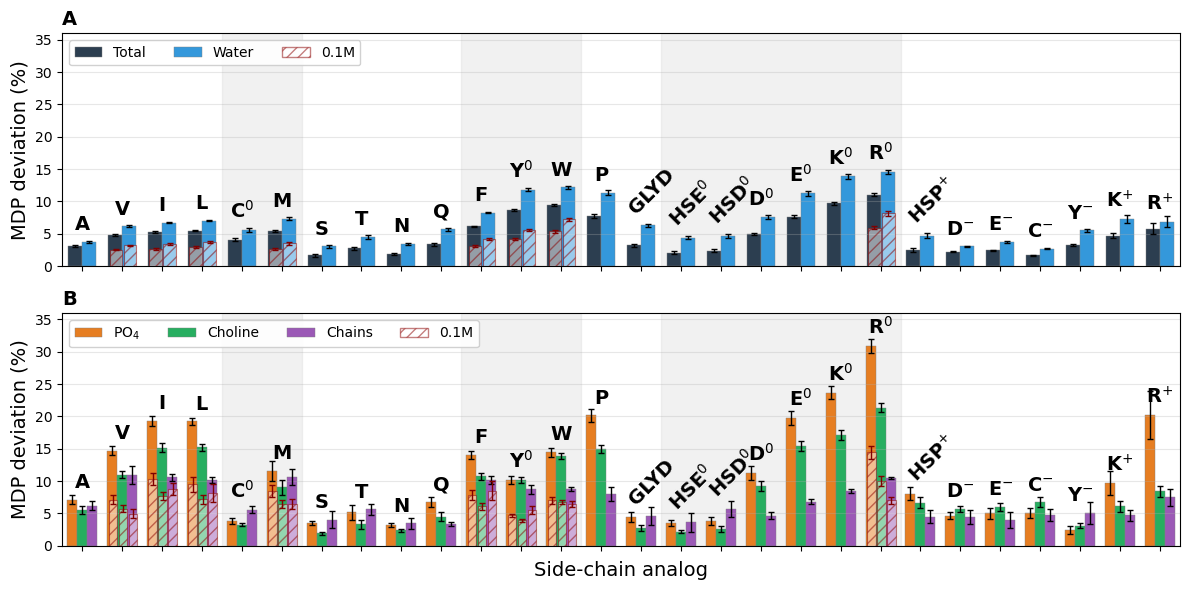

In [8]:
# ABC DEVIATION BETWEEN DENSITY CURVES -- from pre-computed CSV
from matplotlib.patches import Patch

df_dd = pd.read_csv(csv_dens_dev)

profile = ["total", "water", "phosphate", "choline", "chains"]
profile_label = ['Total', 'Water', 'PO$_4$', 'Choline', 'Chains']

data_profiles = [df_dd[f'{p}_mean'].tolist() for p in profile]
se_profiles = [df_dd[f'{p}_se'].tolist() for p in profile]

x_pos = np.arange(N_MAIN)

# ══════════════════════════════════════════════════════════════════════
# TWO-PANEL FIGURE
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

def add_category_backgrounds(ax, category_ranges, ymax):
    for i, (start, end) in enumerate(category_ranges):
        if i % 2 == 1:
            ax.axvspan(start - 0.5, end + 0.5, color='lightgray', alpha=0.3, zorder=0)

# ─── Panel A: Total + Water (grouped bars) ────────────────────────────
ax = axes[0]
bar_width = 0.35
offset = bar_width / 2

add_category_backgrounds(ax, category_ranges, 35)

ax.bar(x_pos - offset, data_profiles[0][:N_MAIN], bar_width, label='Total', color='#2c3e50', 
       edgecolor='grey', linewidth=0.3)
ax.errorbar(x_pos - offset, data_profiles[0][:N_MAIN], se_profiles[0][:N_MAIN], fmt='none', 
            color='black', capsize=2, linewidth=1, zorder=4)

ax.bar(x_pos + offset, data_profiles[1][:N_MAIN], bar_width, label='Water', color='#3498db', 
       edgecolor='grey', linewidth=0.3)
ax.errorbar(x_pos + offset, data_profiles[1][:N_MAIN], se_profiles[1][:N_MAIN], fmt='none', 
            color='black', capsize=2, linewidth=1, zorder=4)

# 0.1M variants as red hatched bars overlaid (transparent fill)
for idx, xmap in VARIANTS_01M.items():
    for j, prof_idx in enumerate([0, 1]):
        xv = xmap + (-offset if j == 0 else offset)+0.02
        ax.bar(xv, data_profiles[prof_idx][idx], bar_width-0.04,
               facecolor='white', edgecolor='darkred', linewidth=0.8, hatch='///', zorder=5, alpha=0.5)
        ax.errorbar(xv, data_profiles[prof_idx][idx], se_profiles[prof_idx][idx],
                    fmt='none', color='maroon', capsize=2, linewidth=1, zorder=6)

handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor='white', edgecolor='darkred', hatch='///', alpha=0.5))
labels.append('0.1M')

max_vals_top = [max(data_profiles[0][i], data_profiles[1][i]) for i in range(N_MAIN)]
for i, (val, label) in enumerate(zip(max_vals_top, ll[:N_MAIN])):
    if i in rotated_indices:
        ax.text(x_pos[i]-0.4, val + 1.2, label, ha='left', va='bottom', fontsize=14, 
                fontweight='bold', rotation=45)
    else:
        ax.text(x_pos[i], val + 1.2, label, ha='center', va='bottom', fontsize=14, 
                fontweight='bold')

ax.set_ylabel('MDP deviation (%)', fontsize=14)
ax.set_ylim(0, 36)
ax.legend(handles=handles, labels=labels, loc='upper left', fontsize=10, framealpha=0.9, ncol=3)
ax.grid(axis='y', alpha=0.3, zorder=1)
ax.set_title('A', fontsize=14, fontweight='bold', loc='left')
ax.set_xlim(-0.5, N_MAIN - 0.5)

# ─── Panel B: Membrane components (PO4, Choline, Chains) ──────────────
ax = axes[1]
n_components = 3
bar_width = 0.25
offsets = [-bar_width, 0, bar_width]

add_category_backgrounds(ax, category_ranges, 35)

colors = ['#e67e22', '#27ae60', '#9b59b6']
labels_comp = ['PO$_4$', 'Choline', 'Chains']

for j, (prof_idx, color, lbl) in enumerate(zip([2, 3, 4], colors, labels_comp)):
    ax.bar(x_pos + offsets[j], data_profiles[prof_idx][:N_MAIN], bar_width, 
           label=lbl, color=color, edgecolor='grey', linewidth=0.3)
    ax.errorbar(x_pos + offsets[j], data_profiles[prof_idx][:N_MAIN], se_profiles[prof_idx][:N_MAIN], 
                fmt='none', color='black', capsize=2, linewidth=1, zorder=4)

# 0.1M variants as red hatched bars overlaid (transparent fill)
for idx, xmap in VARIANTS_01M.items():
    for j, prof_idx in enumerate([2, 3, 4]):
        xv = xmap + offsets[j]+0.02
        ax.bar(xv, data_profiles[prof_idx][idx], bar_width-0.04,
               facecolor='white', edgecolor='darkred', linewidth=0.8, hatch='///', zorder=5, alpha=0.5)
        ax.errorbar(xv, data_profiles[prof_idx][idx], se_profiles[prof_idx][idx],
                    fmt='none', color='maroon', capsize=2, linewidth=1, zorder=6)

handles_b, labels_b = ax.get_legend_handles_labels()
handles_b.append(Patch(facecolor='white', edgecolor='darkred', hatch='///', alpha=0.5))
labels_b.append('0.1M')

max_vals_bottom = [max(data_profiles[j][i] for j in [2, 3, 4]) for i in range(N_MAIN)]
for i, (val, label) in enumerate(zip(max_vals_bottom, ll[:N_MAIN])):
    if i in rotated_indices:
        ax.text(x_pos[i]-0.4, val + 1.2, label, ha='left', va='bottom', fontsize=14, 
                fontweight='bold', rotation=45)
    else:
        ax.text(x_pos[i], val + 1.2, label, ha='center', va='bottom', fontsize=14, 
                fontweight='bold')

ax.set_xlabel('Side-chain analog', fontsize=14)
ax.set_ylabel('MDP deviation (%)', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels([])
ax.set_ylim(0, 36)
ax.legend(handles=handles_b, labels=labels_b, loc='upper left', fontsize=10, ncol=4, framealpha=0.9)
ax.grid(axis='y', alpha=0.3, zorder=1)
ax.set_title('B', fontsize=14, fontweight='bold', loc='left')
ax.set_xlim(-0.5, N_MAIN - 0.5)

plt.tight_layout()
plt.savefig(plots + 'FigureS6.png', bbox_inches='tight', dpi=300, transparent=True)
plt.show()